Aggregation Model

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

## import data from particle concentration, backscatter, fluorescence
part_conc_490 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="4903659_binned_small_removed").iloc[:, 1:]
part_conc_699 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="6990636_binned_small_removed").iloc[:, 1:]

bbp_490 = pd.read_excel("BBP_binned.xlsx", sheet_name="4903659")
bbp_699 = pd.read_excel("BBP_binned.xlsx", sheet_name="6990636")

chla_fluor_490 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="4903659")
chla_fluor_699 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="6990636")

# define depth array, time array (profiles)
depth = part_conc_490["depth_bin"].iloc[:60]
time_490 = pd.Series(range(1, 45))
time_699 = pd.Series(range(1, 78)) 


In [8]:
## separating float 4903659 profiles into individual UVP6 dataframes through dot notation
# this does not contain backscatter or fluorescence yet

# Create container object
f490 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_490.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_490)]

skip_numbers = {13, 19}

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_490.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f490, attr_name, block)

    section_number += 1


#print([attr for attr in dir(f490) if attr.startswith("p")])

# Export an individual profile here (in case one needs checking!)
#f490.p7.to_excel("f490.p7.xlsx", index=False)




## tada, doing the same with 6990636 
# this does not contain backscatter or fluorescence yet

# Create container object
f699 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_699.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_699)]

skip_numbers = {4, 17, 29, 53, 72}   # works too 11/6

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_699.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f699, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
f699.p8.to_excel("f699.p8.xlsx", index=False)


c:\ProgramData\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\ProgramData\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


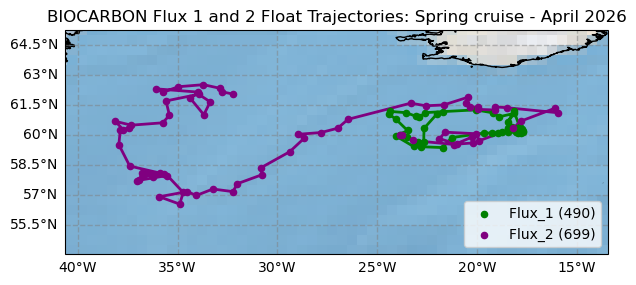

'"\n# Plotting particle concentration data with time\nfig, ax = plt.subplots()\n\n# Particle size 102 data for 490\n# time = (float numbers/dates)\n# y = (data from all profiles for f490)\n\n# Create figure and axes\nfig, ax = plt.subplots()\n\n# Plot the data\nax.plot(x, y, marker=\'o\')\nax.set_xlabel("X values")\nax.set_ylabel("Y values")\nax.set_title("Simple Line Plot")\nax.grid(True)\nplt.show()\n\n'

In [ ]:
## Creating Figures for Presentation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Argo float trajectories figure

float_data = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data")
lat = float_data.loc[:,"latitude"]
lon = float_data.loc[:,"longitude"]
lat.drop_duplicates(inplace = True), lon.drop_duplicates(inplace = True)

# index of first value of 699 is 44
lat_490 = lat[:44]
lon_490 = lon[:44]
lat_699 = lat[44:]
lon_699 = lon[44:]

# plotting on map

# Create a figure with a map projection
fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.OCEAN) #facecolor='lightblue')
ax.stock_img()

gl = ax.gridlines(draw_labels=True,
                  linewidth=1,
                  color='gray',
                  alpha=0.5,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

# Plot the points
ax.scatter(lon_490, lat_490, color='green', s=20, label="Flux_1 (490)", transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(lon_699, lat_699, color='purple', s=20, label="Flux_2 (699)", transform=ccrs.PlateCarree(), zorder=5)

# Draw lines connecting points
ax.plot(lon_490, lat_490, color='green', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(lon_699, lat_699, color='purple', linewidth=2, transform=ccrs.PlateCarree())

# Set extent (optional: zoom to data)
ax.set_extent([
    lon.min() - 5, lon.max() + 5,
    lat.min() - 5, lat.max() + 5
])

ax.legend(loc='lower right')

plt.title("BIOCARBON Flux 1 and 2 Float Trajectories: Spring cruise - April 2026")
plt.show()
                           

""""
# Plotting particle concentration data with time
fig, ax = plt.subplots()

# Particle size 102 data for 490
# time = (float numbers/dates)
# y = (data from all profiles for f490)

# Create figure and axes
fig, ax = plt.subplots()

# Plot the data
ax.plot(x, y, marker='o')
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.set_title("Simple Line Plot")
ax.grid(True)
plt.show()

"""

In [ ]:
# define parameters of particle size class, fluor, backscatter (maybe do a backscatter POC relationship curve conversion?), eventually turbulence


# input equations for particle dynamics - two size class approach?